<a href="https://colab.research.google.com/github/alex-degarate/ML/blob/main/pre_entrega/shabikes4f.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="darkred">Version: 4f-2    &emsp; &emsp; &emsp; &emsp; 2026-05-17</font>

<font face="Times"><font size="44">
# Análisis de Alquiler de bicicletas </font></font>
    
## Alejandro de Gárate

![Bicicletas](https://github.com/alex-degarate/ML/raw/refs/heads/main/pre_entrega/bikes.png)

Bike Sharing Dataset from:
kaggle/akshmi25npathi/bike-sharing-dataset

## **Antecedentes**

Los sistemas de bicicletas compartidas representan la nueva generación de
alquileres de bicicletas tradicionales, donde todo el proceso, desde la
inscripción y el alquiler hasta la devolución, se ha automatizado.   

Mediante estos sistemas, el usuario puede alquilar fácilmente una bicicleta en
una ubicación determinada y devolverla en otra. Actualmente, existen más de
500 programas de bicicletas compartidas en todo el mundo, que suman más de
500.000 bicicletas. Hoy en día, existe un gran interés en estos sistemas
debido a su importante papel en la gestión del tráfico, el medio ambiente y
la salud.

<br>

Además de las interesantes aplicaciones prácticas de los sistemas de bicicletas
compartidas, las características de los datos que generan los hacen atractivos
para la investigación.    
A diferencia de otros servicios de transporte como el
autobús o el metro, la duración del viaje, la posición de salida y la de
llegada se registran explícitamente en estos sistemas.  
Esta característica convierte al sistema de bicicletas compartidas en una red
de sensores virtuales que puede utilizarse para monitorizar la movilidad en la
ciudad. Por lo tanto, se espera que la mayoría de los eventos importantes de la
ciudad puedan detectarse mediante el monitoreo de estos datos.

<font color="#008000"> *He elegido este dataset porque ando en bicicleta, me resultó interesante y sale de lo habitual* </font>

## Dataset

El proceso de alquiler de bicicletas compartidas está altamente correlacionado
con las condiciones ambientales y estacionales.   
Por ejemplo, las condiciones climáticas, las precipitaciones, el día de la semana, la estación del año, la hora del día, etc., pueden afectar el comportamiento de los usuarios.

El conjunto de datos principal se relaciona con el registro histórico de dos
años correspondiente a los años 2011 y 2012 del sistema Capital Bikeshare,
Washington D.C., EE. UU.   
Que está disponible públicamente en http://capitalbikeshare.com/system-data.   
Agregamos los datos por hora y por día, y luego extrajimos y añadimos la
información climática y estacional correspondiente.
La información climática se extrajo de http://www.freemeteo.com.

<font color="red">NOTA:</font> (del programador)

El dataset original fue sacado de kaggle, pero debido a que ya tenia columnas manipuladas, se prefirió llevarla a un estado más básico, para ser procesadas.

Por esta razón vamos a partir de otro dataset, pero básicamente con la misma información.

In [1]:
# Importamos las libreria necesaria para trabajar
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Libreria de warnings nos asistiran para ignorar warnings inocuos
import warnings
warnings.filterwarnings('ignore')

# librarias usadas en pre-procesamiento
from sklearn import preprocessing, linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# libraries para evaluar performance
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error


##1. Recolección y Comprensión de los datos

In [2]:
ruta = "https://raw.githubusercontent.com/alex-degarate/ML/main/pre_entrega/"
df = pd.read_csv(ruta + 'hour_ini.csv', index_col=0)

In [3]:
# Obtenemos el nombre de las columnas y el tipo de dato de cada una
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 0 to 17378
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rental_date  17379 non-null  object 
 1   hour         17379 non-null  int64  
 2   feriado      17379 non-null  int64  
 3   clima        17379 non-null  int64  
 4   casual_usr   17379 non-null  int64  
 5   regist_usr   17379 non-null  int64  
 6   count        17379 non-null  int64  
 7   temp         17379 non-null  float64
 8   termic_sens  17379 non-null  float64
 9   humidity     17379 non-null  float64
 10  windspeed    17379 non-null  float64
dtypes: float64(4), int64(6), object(1)
memory usage: 1.6+ MB


**Columnas:**
<pre>
 0   rental_date  fecha de alquiler    (formato ISO)  
 1   hour         hora de alquiler     (0-24)
 2   feriado      si el dia es feriado (según Whashington DC - USA)      
 3   clima        tipo de clima        (tabla de categoria)   
 4   casual_usr   si el usuario es ocasional    
 5   regist_usr   si el usuario esta registrado  
 6   count        cantidad de bicicletas alquiladas en la hora   
 7   temp         temperatura          (grados Celsius)  
 8   termic_sens  sensacion térmica    (grados Celsius)  
 9   humidity     humedad ambiente     (porcentaje)  
10   windspeed    velocidad del viento (km/h)
</pre>

In [ ]:
# Visualizamos los primeros registros para tener una idea de los los datos
df.head()

,rental_date,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed
0,2011-01-01,0,0,1,3,13,16,9.84,14.395,81.0,0.0
1,2011-01-01,1,0,1,8,32,40,9.02,13.635,80.0,0.0
2,2011-01-01,2,0,1,5,27,32,9.02,13.635,80.0,0.0
3,2011-01-01,3,0,1,3,10,13,9.84,14.395,75.0,0.0
4,2011-01-01,4,0,1,0,1,1,9.84,14.395,75.0,0.0


In [ ]:
df.shape
print("Cantidad de registros: ", df.shape[0])
print("Cantidad de  columnas: ", df.shape[1])

Cantidad de registros:  17379
Cantidad de  columnas:  11


## 2. EDA y limpieza de datos

In [4]:
# Revisamos si hay datos nulos o faltantes
df.isnull().sum()

,0
rental_date,0
hour,0
feriado,0
clima,0
casual_usr,0
regist_usr,0
count,0
temp,0
termic_sens,0
humidity,0


No hay datos nulos, ni registros para descartar.

In [5]:
# Revisamos si hay datos duplicados
print("datos duplicados:", df.duplicated().sum() )

datos duplicados: 0


No hay datos registros duplicados

In [ ]:
df.describe()

,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,11.546752,0.028770,1.425283,35.676218,153.786869,189.463088,20.376474,23.788755,62.722884,12.736540
std,6.914405,0.167165,0.639357,49.305030,151.357286,181.387599,7.894801,8.592511,19.292983,8.196795
min,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,0.000000,0.000000
25%,6.000000,0.000000,1.000000,4.000000,34.000000,40.000000,13.940000,16.665000,48.000000,7.001500
50%,12.000000,0.000000,1.000000,17.000000,115.000000,142.000000,20.500000,24.240000,63.000000,12.998000
75%,18.000000,0.000000,2.000000,48.000000,220.000000,281.000000,27.060000,31.060000,78.000000,16.997900
max,23.000000,1.000000,4.000000,367.000000,886.000000,977.000000,41.000000,50.000000,100.000000,56.996900


     
Antes de continuar con el EDA efectuamos algunas transformaciones básicas para poder analizarlo mejor.

In [6]:
# Convertimos rental_date de object a datetime
df["rental_date"] = pd.to_datetime(df["rental_date"])

# extraemos el año a una columna nueva
df["year"] = df["rental_date"].dt.year

In [7]:
# Vemos que años estan presentes
print(f"Años presentes: {df["year"].unique()} ")

Años presentes: [2011 2012] 


In [8]:
# como vemos sólo hay dos años 2011 y 2012
# convertimos la columna en formato Binary 2011= 0, 2012= 1
df["year"] = df["year"] - 2011

In [9]:
# creamos una columna month/mes en base 1-12
df["month"] = df["rental_date"].dt.month

In [ ]:
df.head(5)

,rental_date,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed,year,month
0,2011-01-01,0,0,1,3,13,16,9.84,14.395,81.0,0.0,0,1
1,2011-01-01,1,0,1,8,32,40,9.02,13.635,80.0,0.0,0,1
2,2011-01-01,2,0,1,5,27,32,9.02,13.635,80.0,0.0,0,1
3,2011-01-01,3,0,1,3,10,13,9.84,14.395,75.0,0.0,0,1
4,2011-01-01,4,0,1,0,1,1,9.84,14.395,75.0,0.0,0,1


In [ ]:
df.describe()

,rental_date,hour,feriado,clima,casual_usr,regist_usr,count,temp,termic_sens,humidity,windspeed,year,month
count,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2012-01-02 04:08:34.552045568,11.546752,0.028770,1.425283,35.676218,153.786869,189.463088,20.376474,23.788755,62.722884,12.736540,0.502561,6.537775
min,2011-01-01 00:00:00,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-04 00:00:00,6.000000,0.000000,1.000000,4.000000,34.000000,40.000000,13.940000,16.665000,48.000000,7.001500,0.000000,4.000000
50%,2012-01-02 00:00:00,12.000000,0.000000,1.000000,17.000000,115.000000,142.000000,20.500000,24.240000,63.000000,12.998000,1.000000,7.000000
75%,2012-07-02 00:00:00,18.000000,0.000000,2.000000,48.000000,220.000000,281.000000,27.060000,31.060000,78.000000,16.997900,1.000000,10.000000
max,2012-12-31 00:00:00,23.000000,1.000000,4.000000,367.000000,886.000000,977.000000,41.000000,50.000000,100.000000,56.996900,1.000000,12.000000
std,NaN,6.914405,0.167165,0.639357,49.305030,151.357286,181.387599,7.894801,8.592511,19.292983,8.196795,0.500008,3.438776


<font color="white">.</font>
### Vemos si algunas de las posibles variables predictoras siguen una distribución Normal

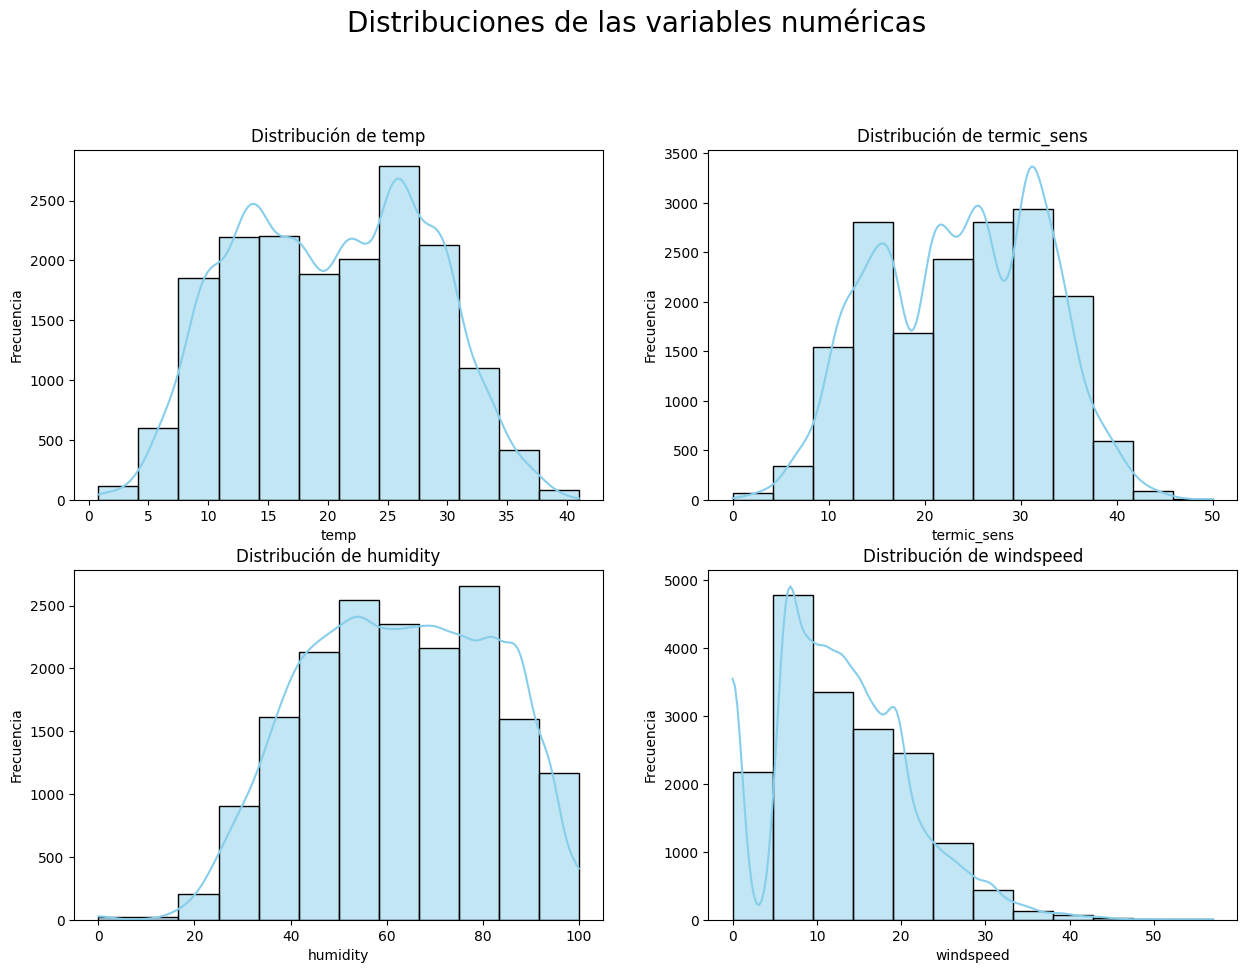

In [ ]:
# @title
# Graficar las distribuciones de las variable numericas
plt.figure(figsize=(15, 10))
plt.suptitle('Distribuciones de las variables numéricas', fontsize=20, y=1.02)
pvariables_pred = ['temp', 'termic_sens', 'humidity', 'windspeed']
for i, col in enumerate( pvariables_pred, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=12, kde=True, color='skyblue')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')


Vemos que las variables siguen una distribución aproximadamente normal.   
Con algunos valores un poco más sesgados para la velocidad del viento.

<font color="white">.</font>
### Vemos si hay valores atípicos (outliers) en las posibles variables predictoras

In [10]:
IQR = df["windspeed"].quantile(0.75) - df["windspeed"].quantile(0.25)
upper_bound = df["windspeed"].quantile(0.75) + (1.5 * IQR)
#outliers = [df[(df["windspeed"] > upper_bound)]
print(f"Outliers en la variable 'windspeed': valores > {upper_bound:.02f} ")


Outliers en la variable 'windspeed': valores > 31.99 


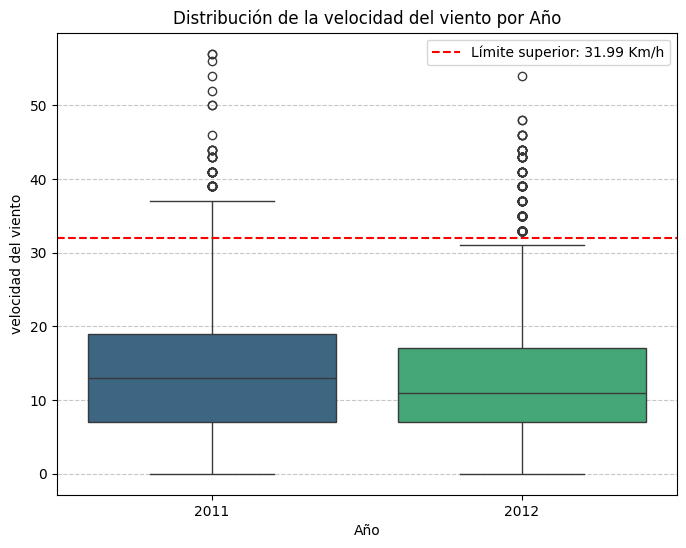

In [ ]:
# @title
# Distribución de la velocidad del viento
plt.figure(figsize=(8, 6))
sns.boxplot(x='year', y='windspeed', data=df.replace({'year': {0: 2011, 1: 2012}}), palette='viridis')
plt.title('Distribución de la velocidad del viento por Año')
plt.xlabel('Año')
plt.ylabel('velocidad del viento')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir una línea horizontal para el upper_bound
plt.axhline(y=upper_bound, color='red', linestyle='--', label=f'Límite superior: {upper_bound:.2f} Km/h')
plt.legend()

plt.show()


En el gráfico de arriba vemos como la variable `windspeed` presenta outliers para valores mayores a (IQR * 1.5)   
Donde IQR es el **Rango Intercuartílico**   
Pero esos valores de viento son valores bastantes normales de viento.   
Por arriba de 50 km/h sólo hay 5 eventos, en más de 17000 registros.   
Son muy pocos, lo que confirma que son eventos raros pero legítimos y no se van a descartar.

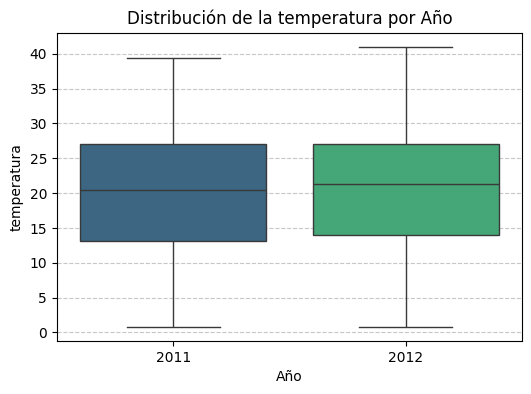

In [11]:
# @title
# Distribución de la temperatura
plt.figure(figsize=(6, 4))
sns.boxplot(x='year', y='temp', data=df.replace({'year': {0: 2011, 1: 2012}}), palette='viridis')
plt.title('Distribución de la temperatura por Año')
plt.xlabel('Año')
plt.ylabel('temperatura')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

No hay outliers en la variable `temp` (temperatura), está en los rangos normales esperables

### Funciones auxiliares para trabajar

In [12]:
# DayOfWeek()
def DOW( nday):
    aDays =["Domingo","Lunes", "Martes", "Miercoles","Jueves","Viernes","Sabado"]
    return aDays[ nday]

# working days goes from 1-5. 0=Domingo, 6=Sabado (no laborable)
# Numeric DOW() 0=Domingo .. 6=Sabado
def NDOW( fecha):
    if type(fecha) == str:
       fecha = pd.to_datetime(fecha)
    # Move the assignment of ndia outside the if block
    ndia = int(fecha.strftime("%w"))
    return ndia

In [13]:
#  Estaciones en el Hemisferio Norte
season_list = ["","invierno","primavera", "verano", "otoño"]

def season( x):
    return season_list[x]

def get_season( fecha):
    ''' obtiene la estacion segun la fecha
    '''
    if type(fecha) == str:
        fecha = pd.to_datetime(fecha)

    dia = fecha.day
    mes = fecha.month

    if mes == 1 or mes == 2:
       nSeason = 1

    elif mes == 3:
       if dia < 21:
          nSeason = 1
       else:
          nSeason = 2
    elif mes == 4 or mes == 5:
        nSeason = 2

    elif mes == 6:
        if dia < 21:
           nSeason = 2
        else:
           nSeason = 3
    elif mes == 7 or mes == 8:
        nSeason = 3

    elif mes == 9:
        if dia < 21:
           nSeason = 3
        else:
           nSeason = 4
    elif mes == 10 or mes == 11:
        nSeason = 4

    elif mes == 12:
        if dia < 21:
           nSeason = 4
        else:
           nSeason = 1
    return nSeason

In [14]:
# CLIMA: Vamos a resumir, conservando la idea:
clima_list = ["",
"Claro",
"Nublado / Niebla",
"LLuvia ligera/ Nevada ligera",
"Tormenta"]


## 3. Preprocesamiento y Preparación de los datos

Vamos a proceder a crear distintas columnas con el fin de poder hacer un analisis más granular y detallado<br> con respecto a los días de alquiler.

* Que día de la semana se hizo el alquiler ?   
  Creamos una columna con esa información => weekday

* El alquiler se hizo en un día laborable ?   
  Creamos una columna con esa información => workingday  

* El alquiler se hizo en un día feriado   
  Ya posee una columna con esa información => feriado

* El alquiler se hizo en un fin de semana ?    
  Creamos una columna con esa información => weekend
  (aunque en realidad esta implicito en !workingday)

* Los alquileres aumentan con el buen tiempo y por tanto de la estación del año
  en que se encuentre.   
  Creamos una columna con esa información => season


In [15]:
# Creamos una columna con el nro dia de semana Dom =0 .. Sab =6
df["weekday"] = df["rental_date"].apply(NDOW)

In [16]:
# Creamos una columna con esta información => workingday
# Si feriado es 1, workingday debe ser 0. De lo contrario,
# se calcula en función del día de la semana.
df["workingday"] = np.where(df["feriado"] == 1, 0,
                            df["weekday"].apply(lambda x: 1 if (x > 0 and x <6) else 0))

In [17]:
# Creamos una columna con esa información => season
df["season"] = df["rental_date"].apply(get_season)

Reordenamos las columnas

In [18]:
# Reordenamos las columnas
df = df[["rental_date", "hour", "year", "month", "weekday", "workingday", "feriado",
        "season", "temp", "termic_sens", "humidity", "windspeed", "clima",
        "casual_usr",	"regist_usr",	"count"]]


In [19]:
df.head()

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,humidity,windspeed,clima,casual_usr,regist_usr,count
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,81.0,0.0,1,3,13,16
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,8,32,40
2,2011-01-01,2,0,1,6,0,0,1,9.02,13.635,80.0,0.0,1,5,27,32
3,2011-01-01,3,0,1,6,0,0,1,9.84,14.395,75.0,0.0,1,3,10,13
4,2011-01-01,4,0,1,6,0,0,1,9.84,14.395,75.0,0.0,1,0,1,1


### NORMALIZACIÓN
Normalizamos algunas variables numéricas, preparándolas para el modelo:  
El nombre de los campos va a estar precedido por "<font color="darkred">N</font>" indicando que estan normalizados

In [20]:
# @title
df['humidity'].describe()

,humidity
count,17379.000000
mean,62.722884
std,19.292983
min,0.000000
25%,48.000000
50%,63.000000
75%,78.000000
max,100.000000


In [21]:
# Se normaliza la humedad
# Los valores se dividen por 100 (max) porque tenemos un min =0
df['Nhumidity'] = df['humidity'] / 100

In [ ]:
# @title
df['windspeed'].describe()

In [22]:
# Se normaliza el viento
# Los valores se dividen por 57 (max) porque tenemos un min =0
df['Nwindspeed'] = df['windspeed'] / 57

In [ ]:
# @title
df["temp"].describe()

In [23]:
# Se normaliza la temperatura
# Creamos el escalador y aplicamos Min-Max Scaling para normalizar a un rango de [0, 1]
scaler_temp = MinMaxScaler()
df['Ntemp'] = scaler_temp.fit_transform(df[['temp']])

In [ ]:
# @title
df["termic_sens"].describe()

In [24]:
# Se normaliza la sens termica dividiendo / 50
# Los valores se dividen por 50 (max) porque tenemos un min =0
df["Ntermic_sens"] = df["termic_sens"] / 50

In [ ]:
pd.set_option('display.max_columns', None)

.

## Normalizar 'clima' (usando One-Hot Encoding)

La columna 'clima' es una característica categórica.    
Para usarla efectivamente en un modelo de regresión lineal, necesitamos <br>convertirla a un formato numérico usando "one-hot encoding".    
Esto crea nuevas columnas binarias para cada categoria de 'clima'.

In [25]:
# Hacemos una copia de df por las dudas
df_copy = df.copy()

In [ ]:
# @title
# restauro para reiniciar desde este punto
#df = df_copy.copy()

In [26]:
# Normalizar 'clima' con One-Hot Encoding
one_hot_encoder = OneHotEncoder(sparse_output=False, dtype=int)
clima_encoded = one_hot_encoder.fit_transform(df[['clima']])

# Crea un DataFrame con las caracteristicas codificadas
clima_df = pd.DataFrame(clima_encoded, columns=one_hot_encoder.get_feature_names_out(['clima']))

# Eliminar la columna 'clima_4' para evitar multicolinearidad
clima_df = clima_df.drop(columns=['clima_4'])

# Concatenar las caracteristicas de 'clima' al DataFrame original df

# -- IMPORTANTE --
# Hay que elimir la columna 'clima' original de df para evitar errores
#
df = pd.concat([df, clima_df], axis=1)
# BORRARLA luego de la matriz de correlación


In [27]:
# Normalizar 'season' con One-Hot Encoding
OHE = OneHotEncoder(sparse_output=False, dtype=int, drop='first')
season_encoded = OHE.fit_transform(df[['season']])
season_df = pd.DataFrame(season_encoded, columns=OHE.get_feature_names_out(['season']))
df = pd.concat([df, season_df], axis=1)


In [28]:
# Mostramos el DF con nuevas cols de 'clima_' y 'season_'
df.head()

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,...,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_1,clima_2,clima_3,season_2,season_3,season_4
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,...,0.81,0.0,0.224490,0.2879,1,0,0,0,0,0
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,...,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
2,2011-01-01,2,0,1,6,0,0,1,9.02,13.635,...,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
3,2011-01-01,3,0,1,6,0,0,1,9.84,14.395,...,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0
4,2011-01-01,4,0,1,6,0,0,1,9.84,14.395,...,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0


In [ ]:
df.info()

## Preparamos algunos datos para poder graficar la información.   
Y de esta forma, tener una mejor idea de lo que vamos a intentar predecir

In [29]:
# cantidad de registros de 2011
reg_2011 = df[df["year"] == 0].shape[0]
print(f"reg 2011: {reg_2011} registros")

reg 2011: 8645 registros


In [30]:
# cantidad de registros de 2012
reg_2012 = df[df["year"] == 1].shape[0]
print(f"reg 2012: {reg_2012} registros")

print(f"Total reg 2011-2012: {reg_2011 + reg_2012} registros" )

reg 2012: 8734 registros
Total reg 2011-2012: 17379 registros


In [31]:
# agregado por mes y año
total_mes = df.groupby(['year', 'month'])['count'].sum().reset_index()
total_mes['year'] = total_mes['year'].map({0: 2011, 1: 2012})

# agregado total por año
total_year = df.groupby(['year'])['count'].sum().reset_index()
total_year['year'] = total_year['year'].map({0: 2011, 1: 2012})

In [ ]:
total_mes

In [32]:
display(total_year)

# Obtenemos los totales por año
y2011 = total_year.iloc[0,1]
y2012 = total_year.iloc[1,1]


,year,count
0,2011,1243103
1,2012,2049576


In [33]:
delta = (y2012 *100 /y2011) -100
print(f"Incremento en el alquiler: { delta:.02f} % más")

Incremento en el alquiler: 64.88 % más


In [34]:
# calculo de la temp media del año 2011
df_2011 = df[df["year"] == 0]
temp_media_2011 = df_2011["temp"].mean()
print(f"{temp_media_2011:.02f}")

# calculo de la temp media del año 2012
df_2012 = df[df["year"] == 1]
temp_media_2012 = df_2012["temp"].mean()
print(f"{temp_media_2012:.02f}")

20.05
20.70


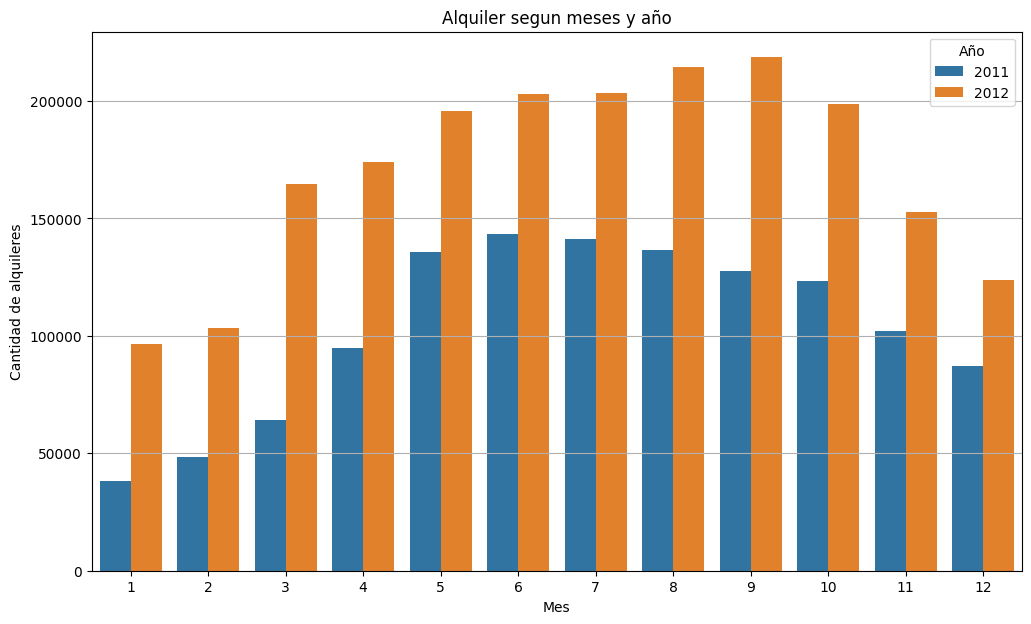

In [ ]:
# @title
plt.figure(figsize=(12, 7))
sns.barplot(x='month', y='count', hue='year', data=total_mes, palette='tab10')
plt.title('Alquiler segun meses y año')
plt.xlabel('Mes')
plt.ylabel('Cantidad de alquileres')
plt.xticks(rotation=0)
plt.legend(title='Año')
plt.grid(axis='y')
plt.show()

In [35]:
# agregado por season y año
total_season = df.groupby(['year', 'season'])['count'].sum().reset_index()
total_season['year'] = total_season['year'].map({0: 2011, 1: 2012})

In [36]:
total_season['season_name'] = total_season['season'].apply(season)

In [ ]:
display(total_season)

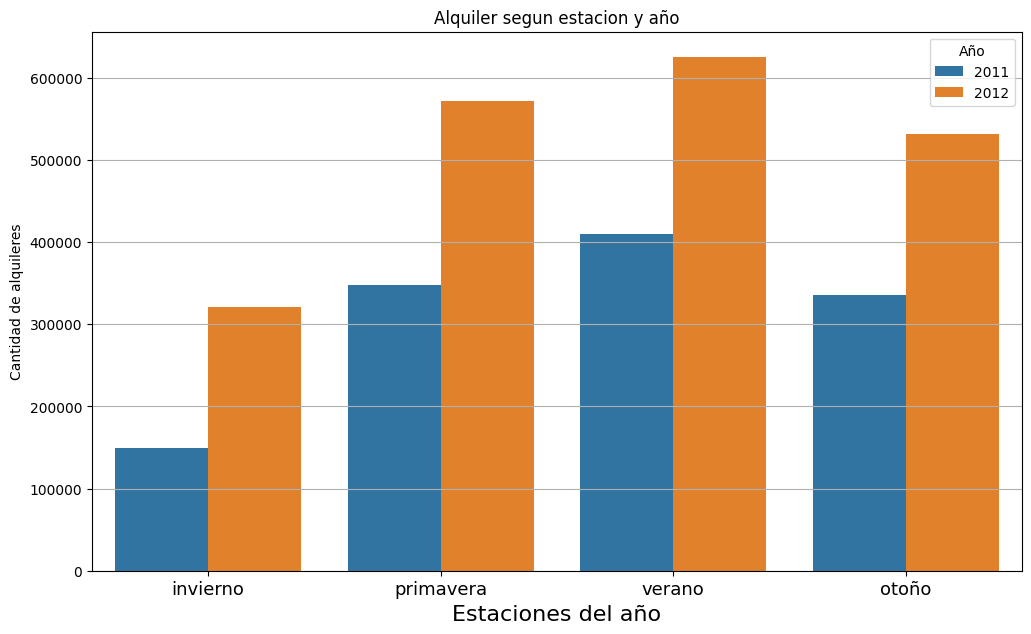

In [37]:
# @title
plt.figure(figsize=(12, 7))
sns.barplot(x='season_name', y='count', hue='year', data=total_season, palette='tab10')
plt.title('Alquiler segun estacion y año')
plt.xlabel('Estaciones del año', size="16")
plt.ylabel('Cantidad de alquileres')
plt.xticks(rotation=0, size=13)
plt.legend(title='Año')
plt.grid(axis='y')
plt.show()

In [38]:
# agregado por hora, season y año
mean_hour = df.groupby(['year', 'season', 'hour'])['count'].mean().reset_index()
mean_hour['year'] = mean_hour['year'].map({0: 2011, 1: 2012})


In [39]:
# Redondeamos el valor de 'count' en mean_hour
mean_hour['count'] = mean_hour['count'].apply(lambda x: round(x))
mean_hour

,year,season,hour,count
0,2011,1,0,19
1,2011,1,1,12
2,2011,1,2,8
3,2011,1,3,5
4,2011,1,4,2
...,...,...,...,...
187,2012,4,19,366
188,2012,4,20,261
189,2012,4,21,195
190,2012,4,22,148


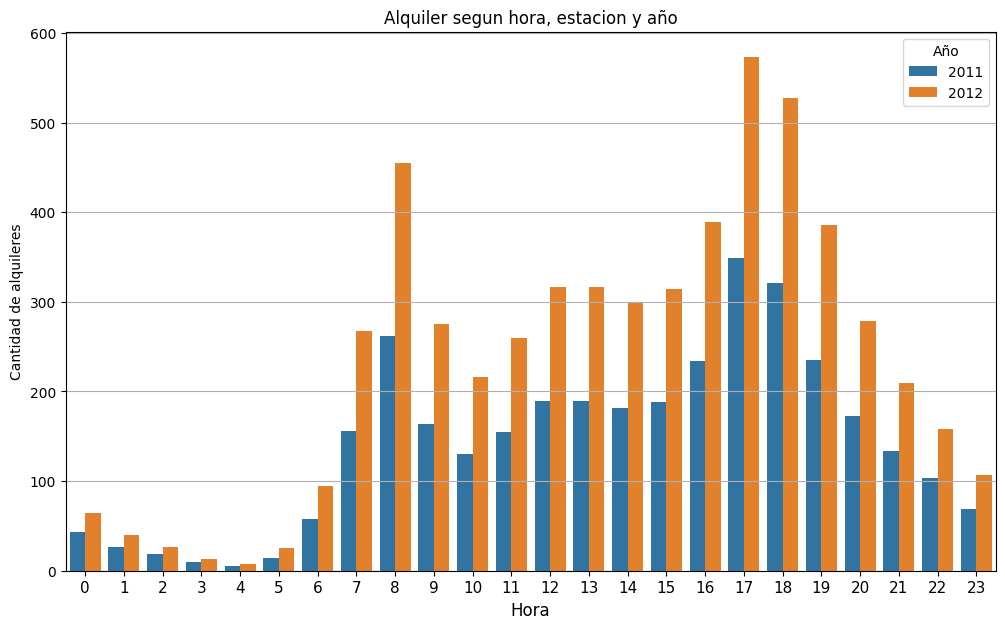

In [40]:
plt.figure(figsize=(12, 7))
sns.barplot(x='hour', y='count', hue='year', data=mean_hour, palette='tab10', errorbar=None)
plt.title('Alquiler segun hora, estacion y año')
plt.xlabel('Hora', size="12")
plt.ylabel('Cantidad de alquileres')
plt.xticks(rotation=0, size=11)
plt.legend(title='Año')
plt.grid(axis='y')
plt.show()

<font color="white">que significa la barra superior en cada hora del grafico<br>
La barra superior en cada hora del gráfico se conoce como barra de error. Dado que el gráfico muestra el promedio de alquileres por hora, esta barra de error representa el intervalo de confianza de la media. <br><br>
En este caso, una barra más larga indica una mayor variabilidad en la cantidad de alquileres de bicicletas para esa hora en particular, lo que significa que el número de alquileres puede fluctuar mucho alrededor del promedio. Una barra más corta sugiere que los alquileres son más consistentes con el promedio para esa hora. Por defecto, Seaborn usa un intervalo de confianza del 95%. </font>

## Matriz de Correlación

Vamos a generar una matriz de correlación para entender las relaciones entre las variables numéricas del dataset.    
Esto nos ayudará a identificar qué variables están fuertemente relacionadas entre sí o con la **variable objetivo** <font color="red">`count`</font>.

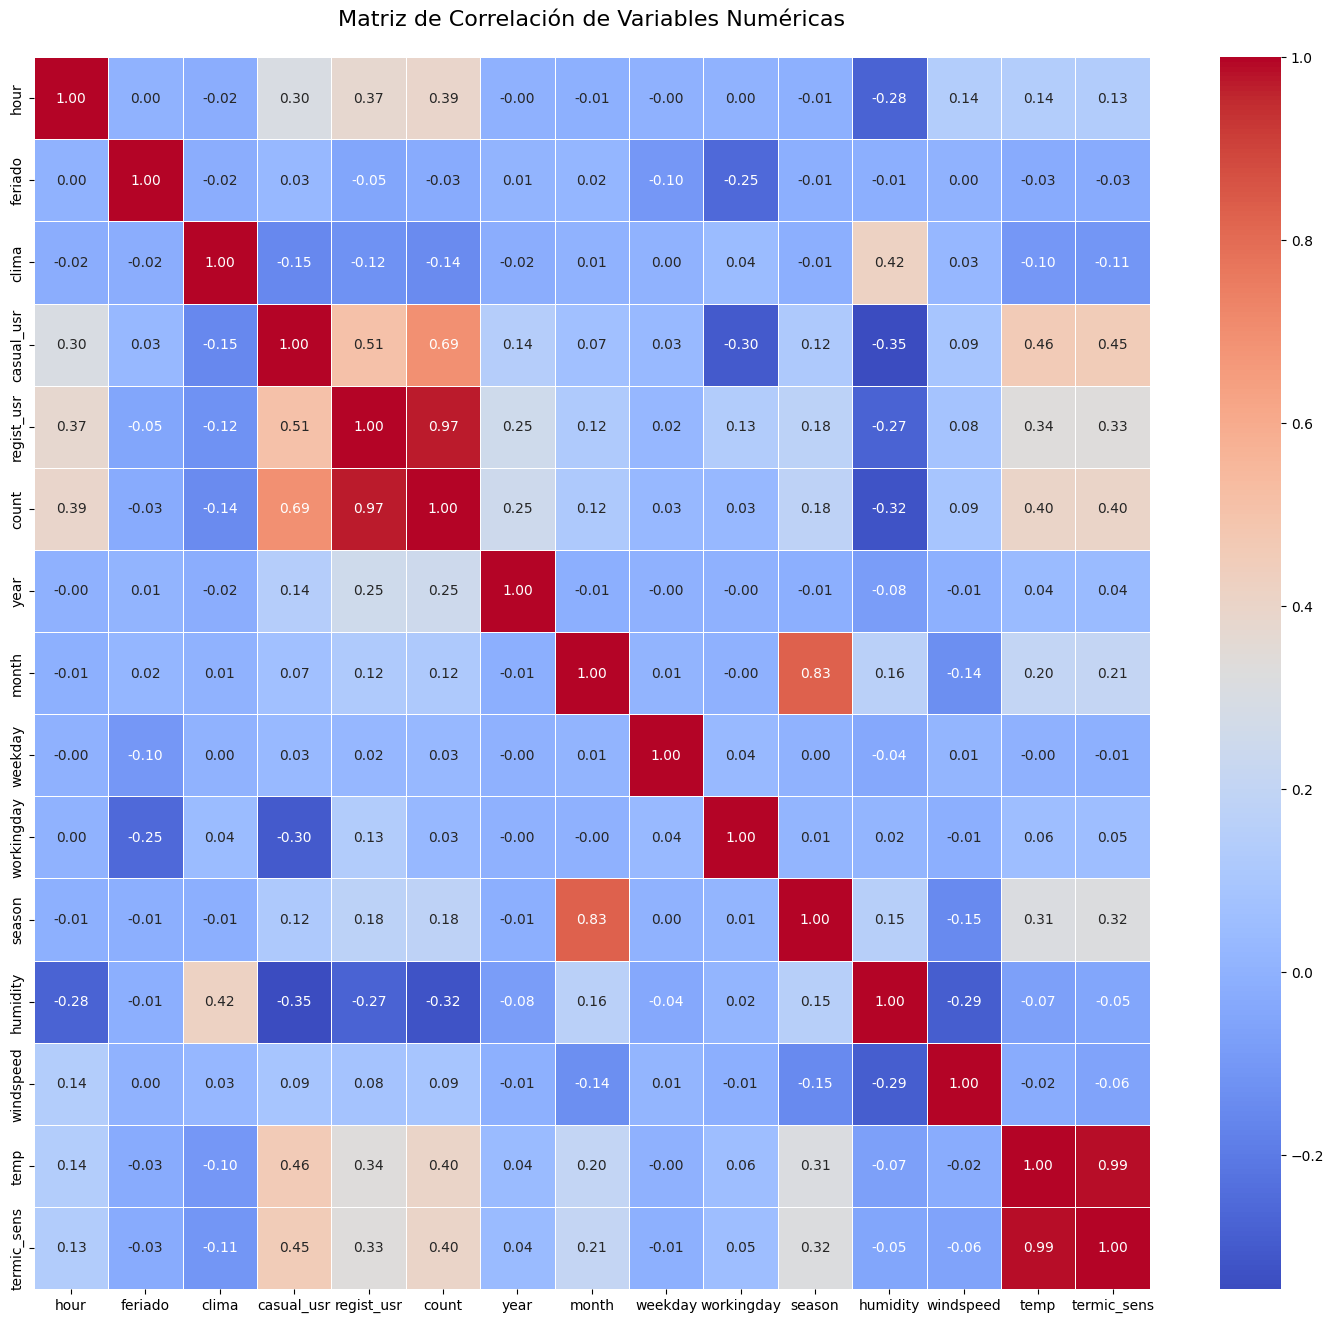

In [41]:
# @title
#import seaborn as sns
#import matplotlib.pyplot as plt

# Seleccionamos las columnas numéricas relevantes para la matriz de correlación
numerical_cols = [
    'hour', 'feriado', 'clima', 'casual_usr', 'regist_usr', 'count',
    'year', 'month', 'weekday', 'workingday', 'season',
    'humidity', 'windspeed', 'temp', 'termic_sens'
]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas\n', size=16)
plt.show()

Como podemos ver en el mapa de calor:   
* usarios registrados tienen correlación alta con la cantidad de alquileres (0.97)
* usuarios casuales tienen correlación media con la cantidad de alquileres (0.69)

<font color="darkred">Por dicho motivo deberemos sacar estas variables de la lista de variables predictoras.  
Porque de lo contrario, sería como si el modelo viera el resultado.

Ahora debemos ver cómo afectan el clima (humedad / lluvia / nieve, temp, viento), consecuencia de season (estación del año) y la hora del día en los alquileres.

La humedad, `humidity` y la velocidad del viento, `windspeed`, tienen una baja correlación con `count`, la variable objetivo.   
La `temp` y la `termic_sens` tienen una correlación media con `count`.   

Las variables `month`, `feriado`, `weekday`, `workingday`, `season` tienen una baja correlación con  `count`

In [42]:
c4 = df[df["clima"] == 4]
print(f"Cantidad de alquileres con clima = 4 ({clima_list[4]}): {c4.shape[0]}")
c4

Cantidad de alquileres con clima = 4 (Tormenta): 3


,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,...,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_1,clima_2,clima_3,season_2,season_3,season_4
585,2011-01-26,16,0,1,3,1,0,1,9.02,9.850,...,0.93,0.386014,0.204082,0.1970,0,0,0,0,0,0
8854,2012-01-09,18,1,1,1,1,0,1,8.20,11.365,...,0.86,0.105319,0.183673,0.2273,0,0,0,0,0,0
9123,2012-01-21,1,1,1,6,0,0,1,5.74,6.820,...,0.86,0.228035,0.122449,0.1364,0,0,0,0,0,0


##Gráficos para establecer una mejor relación entre las variables

<Figure size 500x500 with 0 Axes>

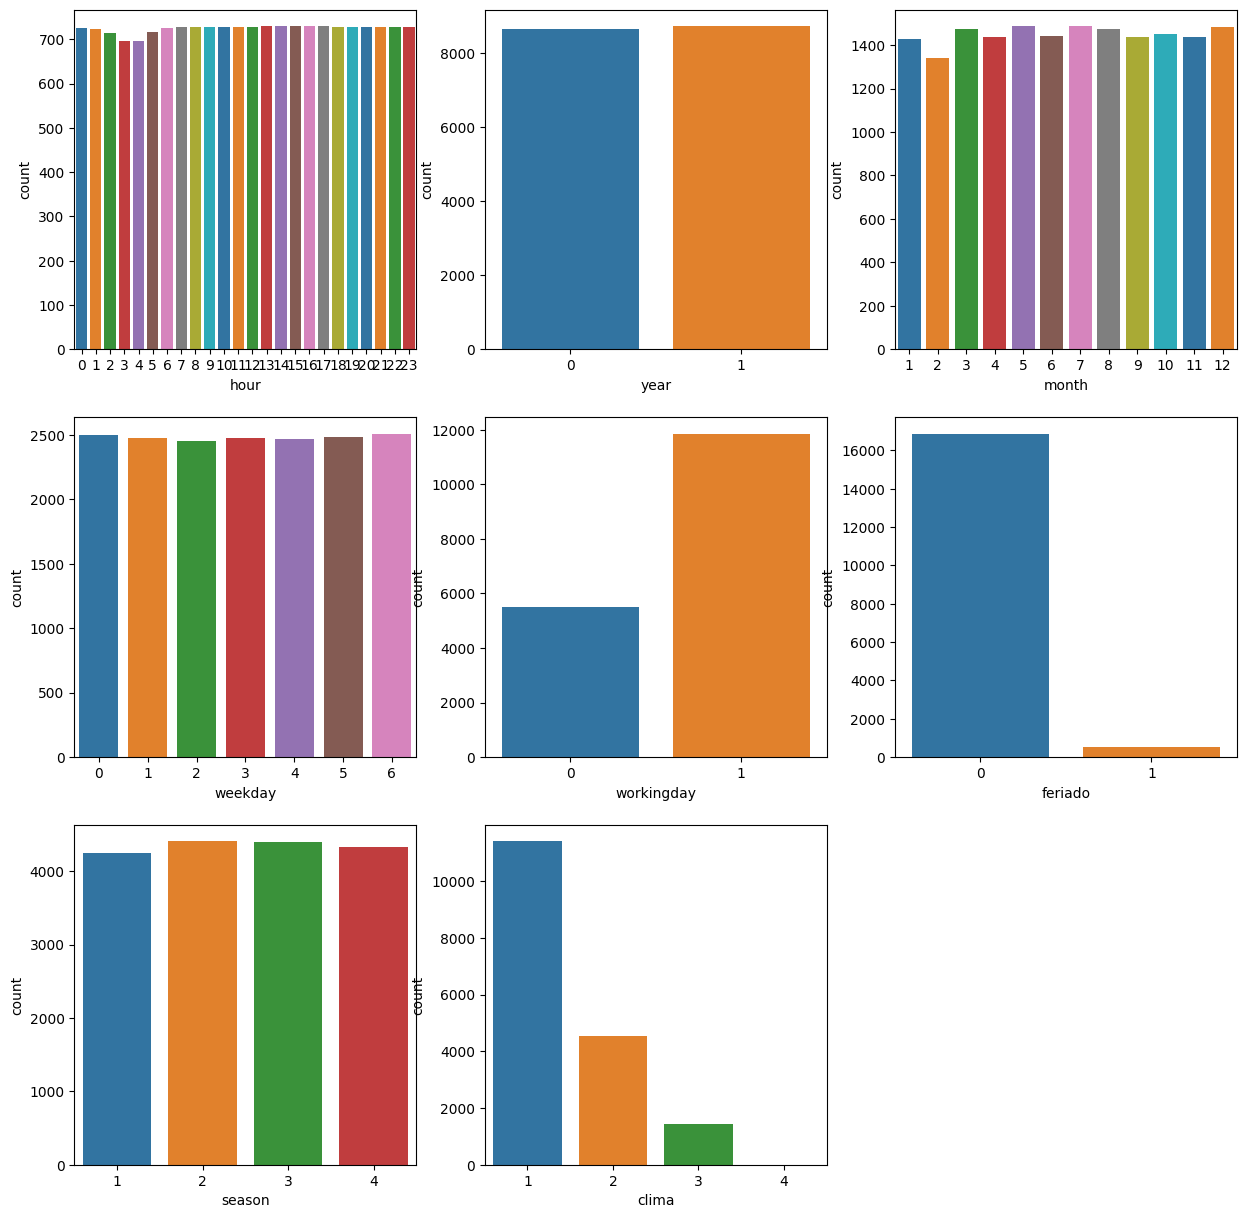

In [43]:
# Contar valores para cada columna que tiene valores contables y graficar esta
# cantidad como "count"

#plt.style.use('ggplot')
plt.figure(figsize=(5,5))
counter=1
plt.figure(figsize=(15,15))

for col in df.columns:
    if col in ['season','year','month', 'hour','feriado', 'clima','weekday','workingday']:

        #print(f"\nthe column {col} has: ",df[col].value_counts())
        plt.subplot(3,3,counter)
        sns.countplot(x=col,data=df, palette='tab10' )
        counter+=1
plt.show()


#### De los gráficos de arriba podemos extraer conclusiones:   
<font color="green">Se renta mayor cantidad: </font>  
* si el dia es laborable (workingday=1)
* si el dia NO es feriado (feriado=0)
* Si hay buenas condiciones meteorologicas(clima=1)  

<font color="darkred">Se renta menor cantidad: </font>
* Disminuye un poco en las primeras horas de la madrugada
* Disminuye un poco en el mes de Febrero (invierno)

Donde el CLIMA es:
1. Cielo claro o parcialmente nublado   
2. Con niebla / nublado
3. Con lluvia ligera / nieve ligera
4. Con Lluvia Intensa / Granizo / Tormenta + Niebla / Nieve + Niebla   

**Hay sólo 3 alquileres cuando el clima == 4 (tormenta)**    
<br>


In [44]:
# Dividimos datos en numerical y categorical features

categorical_features = df[["month", "season", "feriado", "clima"]].astype("category").copy()

numerical_features = df.select_dtypes(exclude = 'object')


In [45]:
categorical_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 0 to 17378
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   month    17379 non-null  category
 1   season   17379 non-null  category
 2   feriado  17379 non-null  category
 3   clima    17379 non-null  category
dtypes: category(4)
memory usage: 204.5 KB


In [46]:
categorical_features.head()

,month,season,feriado,clima
0,1,1,0,1
1,1,1,0,1
2,1,1,0,1
3,1,1,0,1
4,1,1,0,1


In [47]:
numerical_features.head(2)

,rental_date,hour,year,month,weekday,workingday,feriado,season,temp,termic_sens,...,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_1,clima_2,clima_3,season_2,season_3,season_4
0,2011-01-01,0,0,1,6,0,0,1,9.84,14.395,...,0.81,0.0,0.224490,0.2879,1,0,0,0,0,0
1,2011-01-01,1,0,1,6,0,0,1,9.02,13.635,...,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0


In [ ]:
df.info()

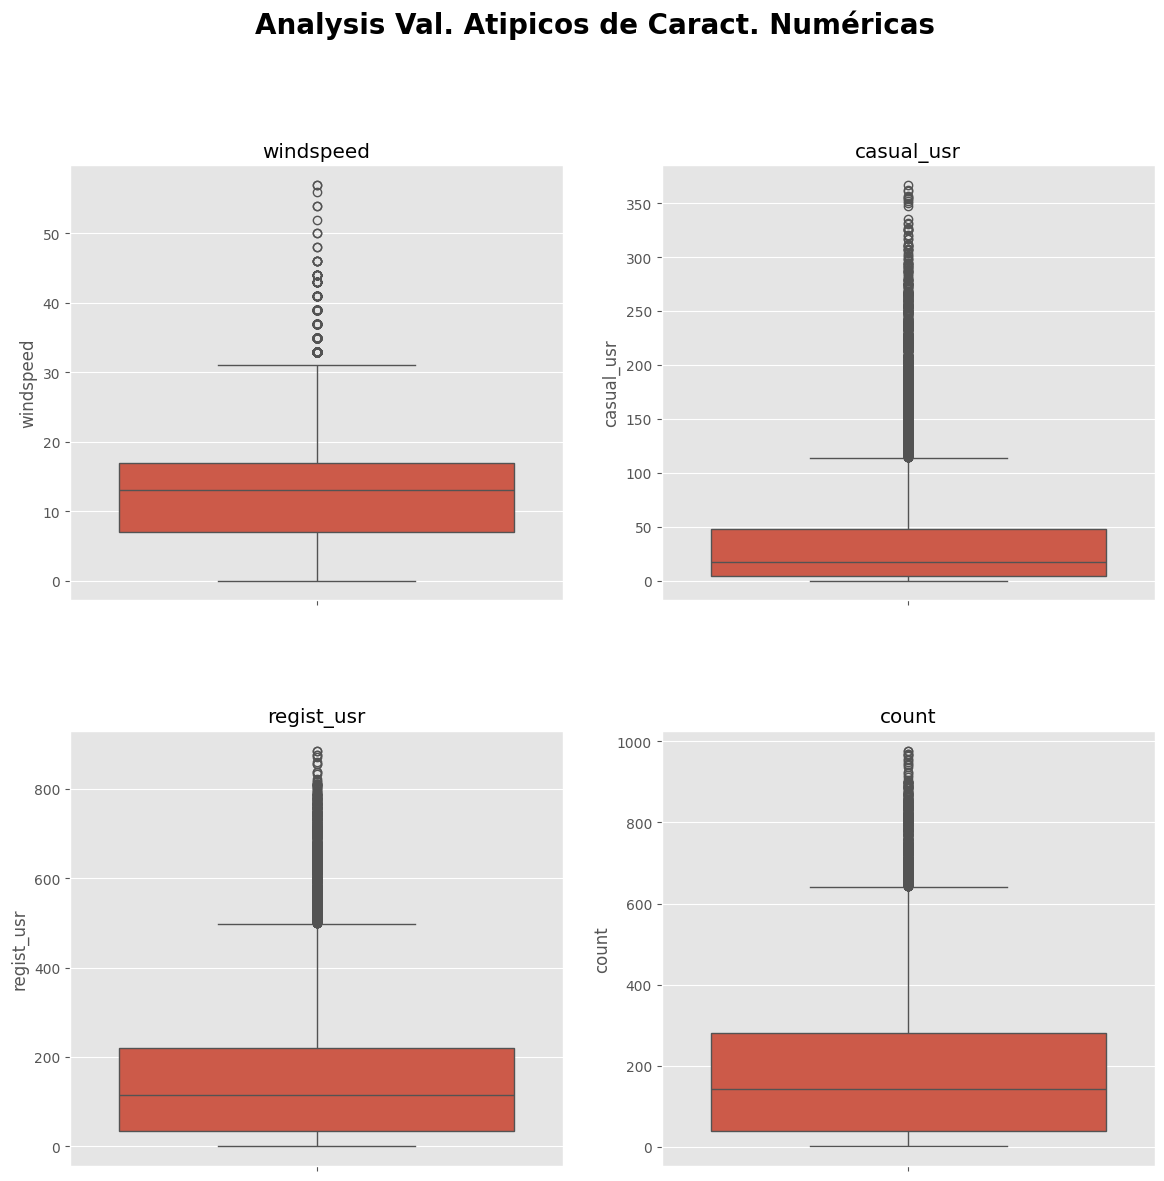

In [48]:
# @title
plt.style.use('ggplot')
# Definimos caract numericas continuas para analisis de los outliers
numerical_feat_4bp = [ 'windspeed', 'casual_usr', 'regist_usr', 'count']

# Ajustamos figsize
plt.figure(figsize=(14, 13))
plt.suptitle('Analysis Val. Atipicos de Caract. Numéricas', fontsize=20, fontweight='bold', y=1.0)

n_features = len(numerical_feat_4bp)
n_cols_plot = 2

# Calculamos numero de filas dinamicamente. Donde "//" es divisor de piso
n_rows_plot = (n_features + n_cols_plot - 1) // n_cols_plot

for i, col in enumerate(numerical_feat_4bp):
    plt.subplot(n_rows_plot, n_cols_plot, i + 1)
    sns.boxplot(df[col])
    plt.title(col)

# Ajustamos espaciado vertical
plt.subplots_adjust(hspace=0.3)
plt.show()


Como vemos en los boxplot, por los outliers se da un crecimiento exagerado de la variable objetivo `count`,    
muy probablemente, explicado por el gran aumento en los usuarios casuales y registrados

# Analizar demanda de bicicletas con respecto a "hour" y otra variable


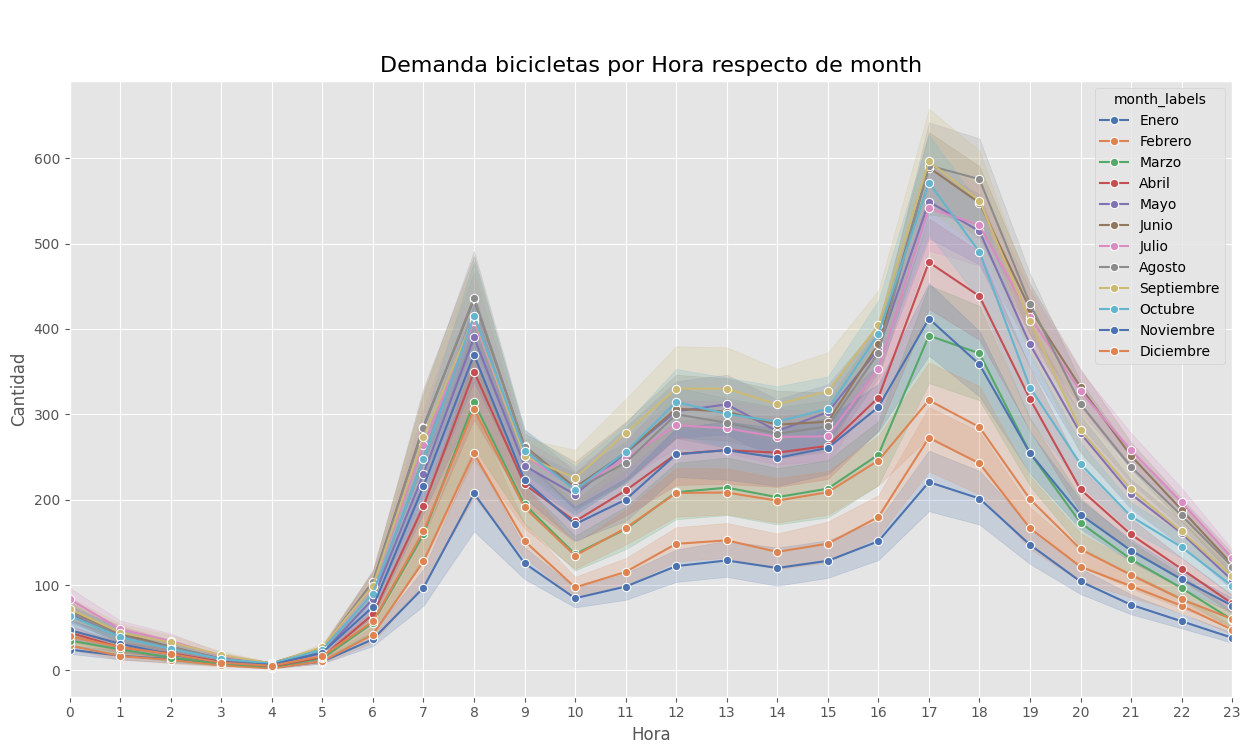

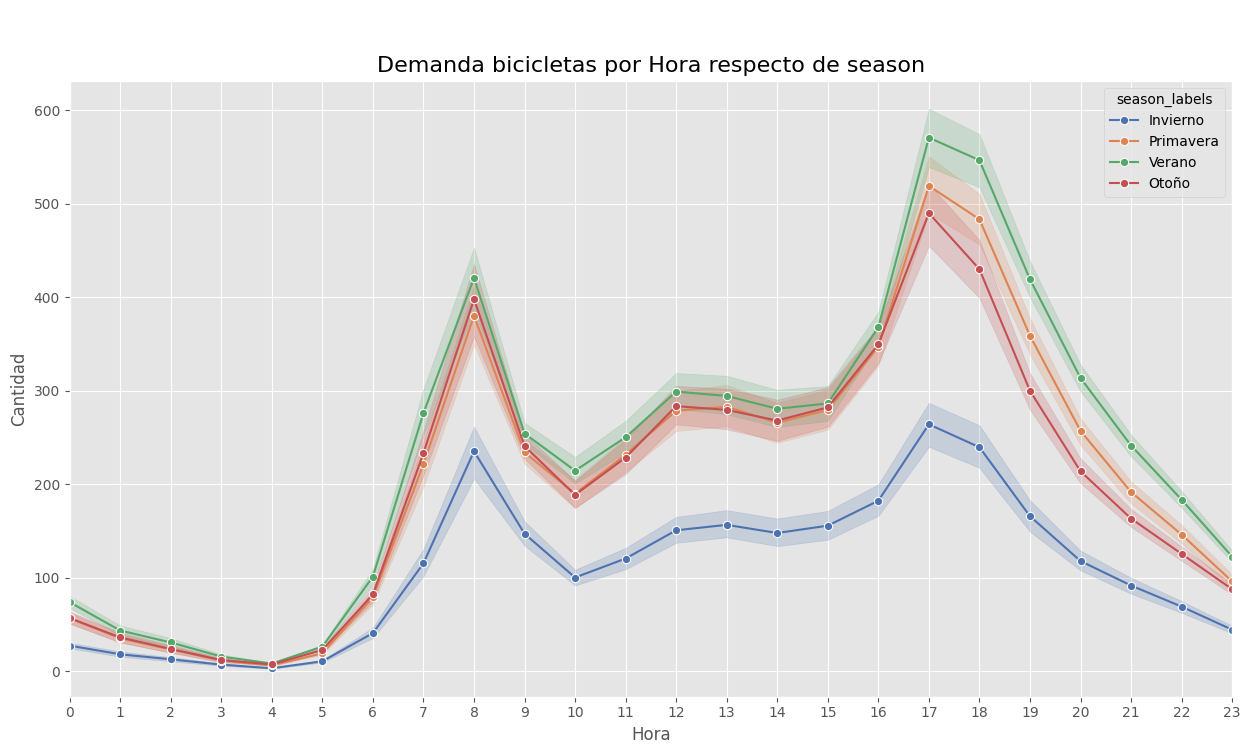

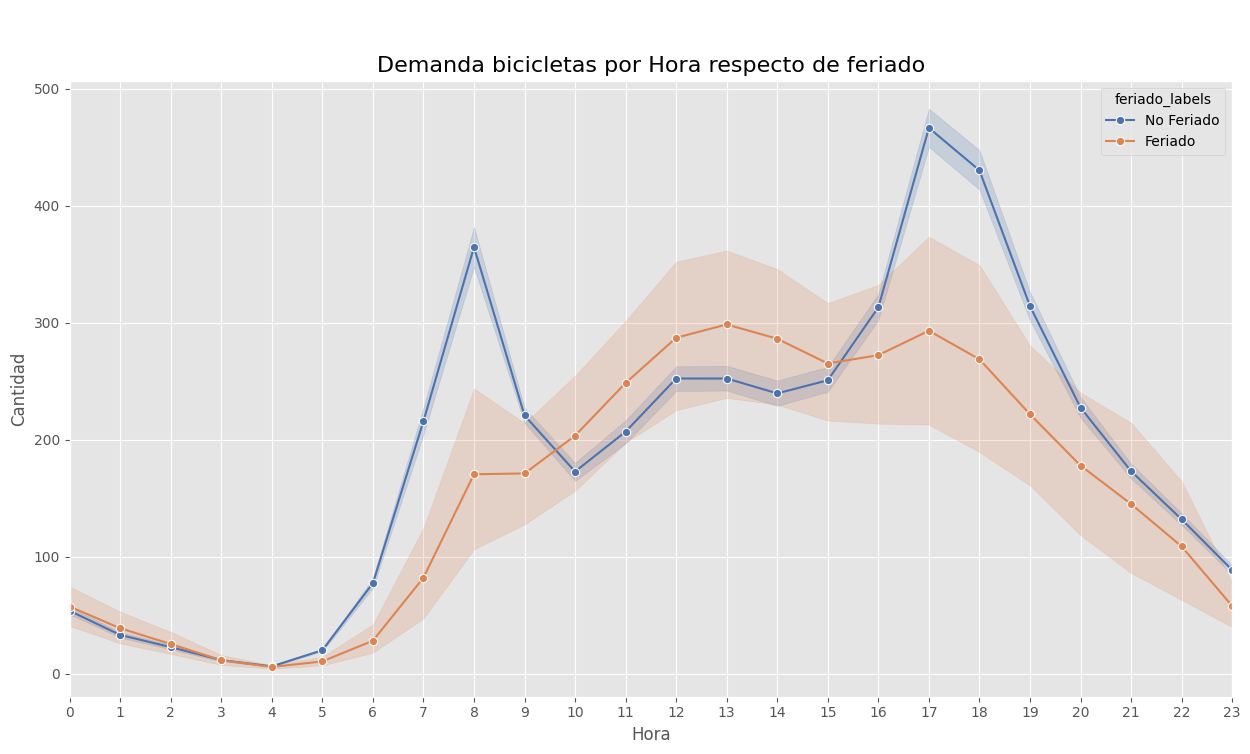

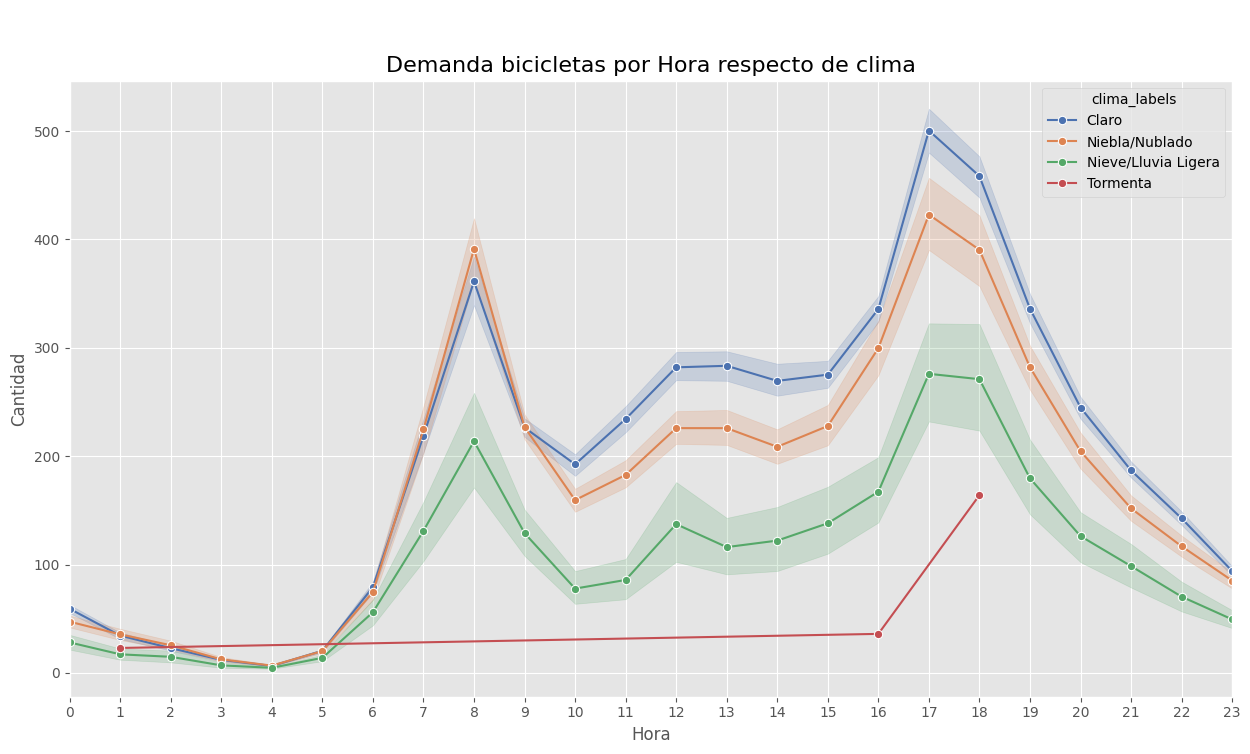

In [49]:
# @title
from re import sub
# Analizar demanda de bicicletas con respecto a "hour" y otra variable

# Definir mapeos para carcateristicas categoricas de etiquetas
month_names = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
season_labels = {
    1: 'Invierno', 2: 'Primavera', 3: 'Verano', 4: 'Otoño'
}
feriado_labels = {
    0: 'No Feriado', 1: 'Feriado'
}
clima_labels = {
    1: 'Claro', 2: 'Niebla/Nublado', 3: 'Nieve/Lluvia Ligera', 4: 'Tormenta'
}

for i in categorical_features:
  #print(i)

  if i == 'hour':
    pass
  else:
    #plt.figure(figsize=(15,8))
    fig, ax = plt.subplots(figsize=(15, 8))

    temp_hue_col_name = i +"_labels"
    if i == 'month':
       df[temp_hue_col_name] = df[i].map(month_names)
       #print(df[temp_hue_col_name])
    elif i == 'season':
       df[temp_hue_col_name] = df[i].map(season_labels)
    elif i == 'feriado':
       df[temp_hue_col_name] = df[i].map(feriado_labels)
    elif i == 'clima':
       df[temp_hue_col_name] = df[i].map(clima_labels)
    else:
       # Fallback for any other unexpected categorical feature
       df[temp_hue_col_name] = df[i]

    sns.lineplot(x= df["hour"], y= df['count'], hue=df[temp_hue_col_name], ax=ax,
                 marker ='o', palette="deep")
    plt.title(f"\n\nDemanda bicicletas por Hora respecto de {i}", size=16)
    ax.set_xticks(range(0, 24, 1))
    plt.xlabel("Hora", size=12)
    plt.ylabel("Cantidad")
    ax.set_xlim(0, 23)
    plt.show()


En los gráficos vemos que hay una gran consistente demanda:
* entre  7-9 hs. => horario de entrada al trabajo, escuelas, colegios...    
* entre 16-19.30 => horario de entrada al trabajo, escuelas, colegios...

In [50]:
# eliminar las columnas agregadas _labels
df = df.drop(columns=['month_labels', 'season_labels', 'feriado_labels', 'clima_labels'])

In [51]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 0 to 17378
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   rental_date   17379 non-null  datetime64[ns]
 1   hour          17379 non-null  int64         
 2   year          17379 non-null  int32         
 3   month         17379 non-null  int32         
 4   weekday       17379 non-null  int64         
 5   workingday    17379 non-null  int64         
 6   feriado       17379 non-null  int64         
 7   season        17379 non-null  int64         
 8   temp          17379 non-null  float64       
 9   termic_sens   17379 non-null  float64       
 10  humidity      17379 non-null  float64       
 11  windspeed     17379 non-null  float64       
 12  clima         17379 non-null  int64         
 13  casual_usr    17379 non-null  int64         
 14  regist_usr    17379 non-null  int64         
 15  count         17379 non-null  int64      

# Separación de variable objetivo y variables predictoras

## Selección de Características para el Modelo Predictivo

Ahora que hemos explorado y preprocesado los datos, seleccionaremos las características que utilizaremos para entrenar nuestro modelo predictivo. La variable objetivo es <font color="red">`count`</font> (cantidad total de alquileres por hora).

Eliminaremos las columnas originales de temperatura, humedad, velocidad del viento y clima, ya que tenemos sus versiones normalizadas (`Ntemp`, `Ntermic_sens`, `Nhumidity`, `Nwindspeed`) o codificadas (`clima_2`, `clima_3`, `clima_4`).    

 <font color="white">
 .
 </font>

 La eliminación de usuarios: `casual_usr` y `regist_usr` porque son componentes de la variable objetivo `count`, y que su inclusión causaría una fuga de datos (data leakage) que podría resulta en un rendimiento del modelo engañosamente alto.    
 Pero por otro lado su no inclusión, margina 2 variables importantes de la predicción y perdería eficiencia la predicción.

Finalmente, `rental_date` también se eliminará porque ya hemos extraído `year`, `month`, y `weekday` de ella.

## Variable Objetivo:
En este dataset, la variable objetivo es <font color="red">`count`</font>, (cantidad de alquileres por hora), porque representa el valor que se intenta predecir.

Se intenta predecir el año siguiente (2012), solamente a partir de las variables predictoras del año 2011:  
<font color="darkgreen">
**hour, year, month, weekday, workingday, feriado, Ntemp, Ntermic_sens, Nhumidity, Nwindspeed,   
clima_1, clima_2, clima_3, season_2,season_3, season_4**</font>

<br>Descartamos las siguientes columnas:   
* **rental_date** (la fecha esta desglosada en year, month, day, weekday y hour)
* **temp, termic_sens, humidity, windspeed** (por sus equivalentes normalizadas)
* **casual_usr, regist_usr** (porque darian el resultado al modelo)

In [52]:
drop_columns = [
    'rental_date', 'temp', 'termic_sens', 'humidity', 'windspeed',
    'casual_usr', 'regist_usr', 'clima', 'season']

In [53]:
# Descartamos las columnas innecesarias y/o perjudiciales
df = df.drop(columns=drop_columns)

In [54]:
df.head()

,hour,year,month,weekday,workingday,feriado,count,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_1,clima_2,clima_3,season_2,season_3,season_4
0,0,0,1,6,0,0,16,0.81,0.0,0.224490,0.2879,1,0,0,0,0,0
1,1,0,1,6,0,0,40,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
2,2,0,1,6,0,0,32,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
3,3,0,1,6,0,0,13,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0
4,4,0,1,6,0,0,1,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0


In [55]:
# Hacemos una copia final de df por las dudas => df2
# las columnas innecesarias estan eliminadas, falta 'count'
df2 = df.copy()

In [56]:
# guardamos una copia a disco
#df2.to_csv('df2.csv', index=False)

In [ ]:
# df2.info()

Vamos a separar:

- `X`: variables predictoras;
- `y`: variable objetivo.

## División de Datos en Conjuntos de Entrenamiento y Prueba

Para evaluar el rendimiento de nuestro modelo de manera realista, dividiremos los datos:
- **Entrenamiento:** Utilizaremos los datos del año 2011.
- **Prueba:** Utilizaremos los datos del año 2012.

Esta estrategia de división es crucial para series de tiempo, ya que evita la fuga de datos del futuro al pasado y simula un escenario de predicción real, donde el modelo debe predecir eventos futuros basándose solo en información pasada.

In [57]:
# Crea un DataFrame con solamente datos de 2011 para entrenamiento
df_2011 = df[df['year'] == 0].copy()

# Crea un DataFrame con solamente datos de 2012 para test / prueba
df_2012 = df[df['year'] == 1].copy()

In [58]:
# Dividir los datos para Entrenamiento (2011)

X_train = df_2011.drop(columns=['year','count'])
y_train = df_2011['count']

In [59]:
# datos de Entrenamiento
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de y_train:", y_train.shape)
print("\nPrimeras 5 filas de X_train:")
display(X_train.head())

print("\nPrimeras 5 filas de y_train:")
display(y_train.head())

Dimensiones de X_train: (8645, 15)
Dimensiones de y_train: (8645,)

Primeras 5 filas de X_train:


,hour,month,weekday,workingday,feriado,Nhumidity,Nwindspeed,Ntemp,Ntermic_sens,clima_1,clima_2,clima_3,season_2,season_3,season_4
0,0,1,6,0,0,0.81,0.0,0.224490,0.2879,1,0,0,0,0,0
1,1,1,6,0,0,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
2,2,1,6,0,0,0.80,0.0,0.204082,0.2727,1,0,0,0,0,0
3,3,1,6,0,0,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0
4,4,1,6,0,0,0.75,0.0,0.224490,0.2879,1,0,0,0,0,0



Primeras 5 filas de y_train:


,count
0,16
1,40
2,32
3,13
4,1


In [60]:
# Dividir los datos para Prueba (2012)

X_test = df_2012.drop(columns=['year','count'])
y_test = df_2012['count']

In [61]:
# datos de Prueba
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_test: (8734, 15)
Dimensiones de y_test: (8734,)


<br>
<center><big>FIN DE LA PRIMERA PARTE (PREENTREGA)<big></center>
<center> -o-O-o-</center>